
# INTERN PORTFOLIO READINESS SCORER
# COMPLETE MACHINE LEARNING PIPELINE

# 1. IMPORT LIBRARIES


In [1]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


# 2. LOAD DATASET


In [2]:
# Replace path if needed
file_path = "Cleaned_Intern_Portal_Human_Readable.xlsx"

# Load dataset
df = pd.read_excel(file_path)

# Create copy
df = df.copy()

# 3. BASIC DATASET INFORMATION

In [3]:

print("\n================ DATASET SHAPE ================")
print(df.shape)

print("\n================ FIRST 5 ROWS ================")
print(df.head())

print("\n================ COLUMN NAMES ================")
print(df.columns)

print("\n================ MISSING VALUES ================")
print(df.isnull().sum())

print("\n================ DATA TYPES ================")
print(df.dtypes)



================ DATASET SHAPE ================
(452, 18)

================ FIRST 5 ROWS ================
                     Domain  Total_Projects  Project_Quality  \
0  Data Science & Analytics               3               62   
1  Data Science & Analytics               1               39   
2  Data Science & Analytics               1               85   
3  Data Science & Analytics               1               39   
4             HR Department               1               25   

                                    Technical_Skills  Documentation Score  \
0  Analytics, Data Analysis, Data Science, Databa...                   63   
1  Analytics, Data Science, Data Visualization, S...                   39   
2  Analytics, Data Analysis, Data Science, Data V...                   87   
3  Analytics, Data Visualization, Python, Sales, ...                   41   
4  Canva, Excel, Linkedin, Ms Excel, Powerpoint, ...                   26   

   Presentation Quality  Business Impact  Con

# 4. HANDLE MISSING VALUES

In [4]:
# Fill categorical missing values
df['Technical_Skills'] = df['Technical_Skills'].fillna('Unknown')
df['Languages Used'] = df['Languages Used'].fillna('Unknown')

# 5. FEATURE ENGINEERING

In [5]:
# ------------------------------------------------------------
# Feature 1: Count number of technical skills
# ------------------------------------------------------------

df['Skill_Count_From_Text'] = df['Technical_Skills'].apply(
    lambda x: len(str(x).split(','))
)

# ------------------------------------------------------------
# Feature 2: Count number of languages used
# ------------------------------------------------------------

df['Language_Count_From_Text'] = df['Languages Used'].apply(
    lambda x: len(str(x).split(','))
)

# ------------------------------------------------------------
# Feature 3: README words per project
# ------------------------------------------------------------

df['README_Per_Project'] = (
    df['README Word Count'] / (df['Total_Projects'] + 1)
)

# ------------------------------------------------------------
# Feature 4: Business impact per project
# ------------------------------------------------------------

df['Impact_Per_Project'] = (
    df['Business Impact'] / (df['Total_Projects'] + 1)
)

# ------------------------------------------------------------
# Feature 5: Combined quality score
# ------------------------------------------------------------

df['Combined_Quality'] = (
    df['Project_Quality'] +
    df['Documentation Score'] +
    df['Presentation Quality']
) / 3

# ------------------------------------------------------------
# Feature 6: Portfolio consistency index
# ------------------------------------------------------------

df['Portfolio_Consistency_Index'] = (
    df['Consistency Score'] * 0.7 +
    df['Commit Frequency'] * 0.3
)

# 6. REMOVE DATA LEAKAGE COLUMNS

In [6]:
# These columns directly reveal the target
# and should NOT be used for training

leakage_columns = [
    'Readiness Score',
    'Raw Weighted Score',
    'Readiness Category',
    'Target_Encoded'
]


# 7. DEFINE FEATURES AND TARGET

In [7]:
# Input features
X = df.drop(columns=leakage_columns)

# Target variable
# 0 = Needs Improvement
# 1 = Almost Ready
# 2 = Job Ready

y = df['Target_Encoded']



# 8. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS

In [8]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns

print("\n================ NUMERIC FEATURES ================")
print(numeric_features)

print("\n================ CATEGORICAL FEATURES ================")
print(categorical_features)


================ NUMERIC FEATURES ================
Index(['Total_Projects', 'Project_Quality', 'Documentation Score',
       'Presentation Quality', 'Business Impact', 'Consistency Score',
       'Commit Frequency', 'README Word Count', 'Project Diversity',
       'Num_Technical_Skills', 'Num_Languages', 'Skill_Count_From_Text',
       'Language_Count_From_Text', 'README_Per_Project', 'Impact_Per_Project',
       'Combined_Quality', 'Portfolio_Consistency_Index'],
      dtype='object')

================ CATEGORICAL FEATURES ================
Index(['Domain', 'Technical_Skills', 'Languages Used'], dtype='object')


# 9. PREPROCESSING PIPELINE

In [9]:
# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# ------------------------------------------------------------
# Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


# 10. TRAIN TEST SPLIT

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================ TRAIN SHAPE ================")
print(X_train.shape)

print("\n================ TEST SHAPE ================")
print(X_test.shape)



================ TRAIN SHAPE ================
(361, 20)

================ TEST SHAPE ================
(91, 20)


# 11. CREATE MACHINE LEARNING MODELS

In [11]:
# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=2000,
                C=1.0,
                penalty='l2',
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

decision_tree_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=42
            )
        )
    ]
)


# 12. STORE MODELS

In [12]:
models = {
    'Logistic Regression': logistic_pipeline,
    'Decision Tree': decision_tree_pipeline,
    'Random Forest': random_forest_pipeline
}


# 13. TRAIN AND EVALUATE MODELS


TRAINING MODEL: Logistic Regression

Train Accuracy: 0.9474
Test Accuracy: 0.9011
Cross Validation Accuracy: 0.8673
Accuracy Gap: 0.0463
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Needs Improvement       0.89      0.93      0.91        44
     Almost Ready       0.89      0.80      0.84        30
        Job Ready       0.94      1.00      0.97        17

         accuracy                           0.90        91
        macro avg       0.91      0.91      0.91        91
     weighted avg       0.90      0.90      0.90        91



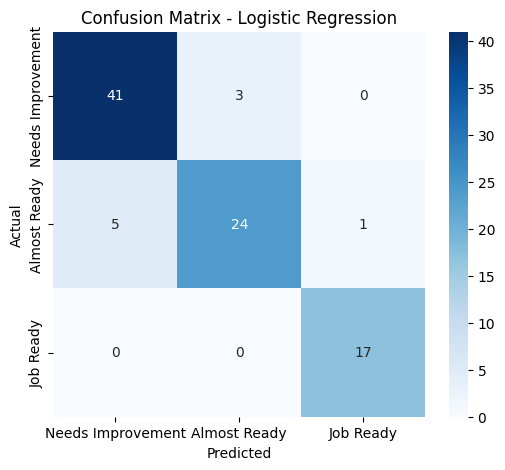


TRAINING MODEL: Decision Tree

Train Accuracy: 0.9501
Test Accuracy: 0.9011
Cross Validation Accuracy: 0.9137
Accuracy Gap: 0.0490
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Needs Improvement       0.93      0.86      0.89        44
     Almost Ready       0.82      0.90      0.86        30
        Job Ready       1.00      1.00      1.00        17

         accuracy                           0.90        91
        macro avg       0.92      0.92      0.92        91
     weighted avg       0.90      0.90      0.90        91



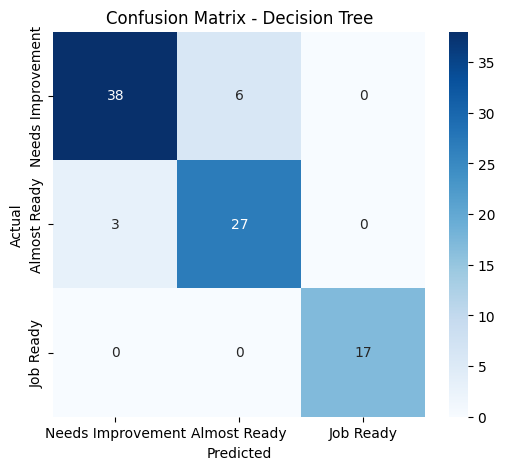


TRAINING MODEL: Random Forest

Train Accuracy: 0.9114
Test Accuracy: 0.9011
Cross Validation Accuracy: 0.9005
Accuracy Gap: 0.0103
Good Generalization

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Needs Improvement       0.85      1.00      0.92        44
     Almost Ready       0.96      0.73      0.83        30
        Job Ready       1.00      0.94      0.97        17

         accuracy                           0.90        91
        macro avg       0.93      0.89      0.91        91
     weighted avg       0.91      0.90      0.90        91



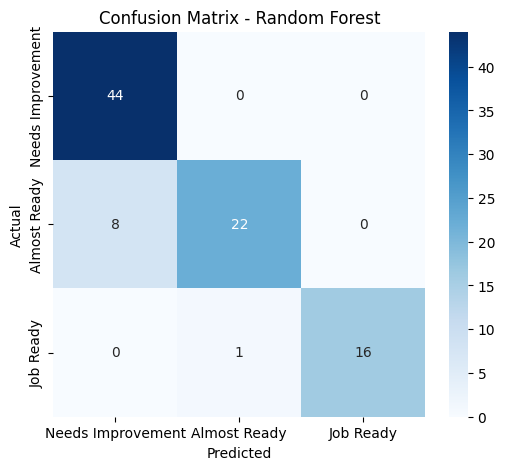

In [13]:

results = {}

for model_name, model in models.items():

    print("\n====================================================")
    print(f"TRAINING MODEL: {model_name}")
    print("====================================================")

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # --------------------------------------------------------
    # Cross Validation
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results[model_name] = {
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'CV Accuracy': cv_scores.mean()
    }

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(f"\nTrain Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Cross Validation Accuracy: {cv_scores.mean():.4f}")

    # --------------------------------------------------------
    # Overfitting check
    # --------------------------------------------------------

    accuracy_gap = train_accuracy - test_accuracy

    print(f"Accuracy Gap: {accuracy_gap:.4f}")

    if accuracy_gap > 0.10:
        print("Possible Overfitting Detected")
    else:
        print("Good Generalization")

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nCLASSIFICATION REPORT")

    print(
        classification_report(
            y_test,
            y_pred_test,
            target_names=[
                'Needs Improvement',
                'Almost Ready',
                'Job Ready'
            ]
        )
    )

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(y_test, y_pred_test)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[
            'Needs Improvement',
            'Almost Ready',
            'Job Ready'
        ],
        yticklabels=[
            'Needs Improvement',
            'Almost Ready',
            'Job Ready'
        ]
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


# 14. MODEL COMPARISON

In [14]:
results_df = pd.DataFrame(results).T

print("\n====================================================")
print("FINAL MODEL COMPARISON")
print("====================================================")

print(results_df)



FINAL MODEL COMPARISON
                     Train Accuracy  Test Accuracy  CV Accuracy
Logistic Regression        0.947368       0.901099     0.867253
Decision Tree              0.950139       0.901099     0.913724
Random Forest              0.911357       0.901099     0.900488


# 15. VISUALIZE MODEL PERFORMANCE

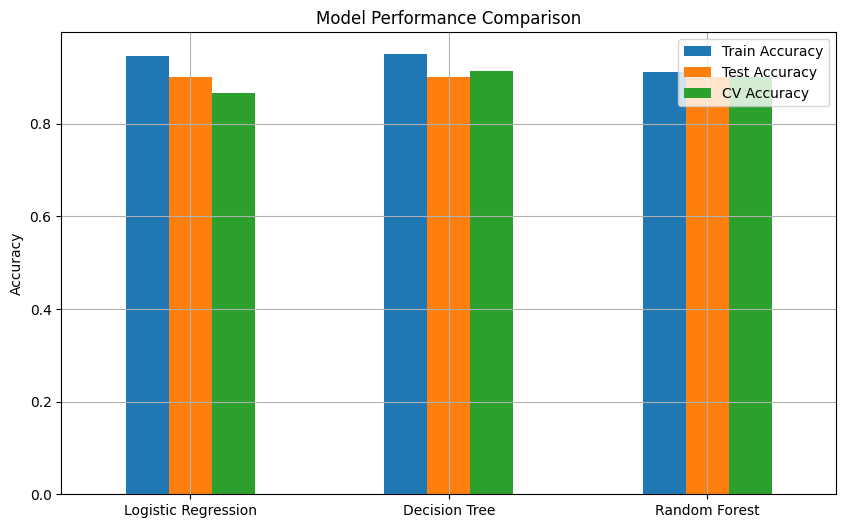

In [15]:
results_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.grid(True)

plt.show()



# 16. FIND BEST MODEL

In [16]:
best_model_name = results_df['Test Accuracy'].idxmax()

print("\n====================================================")
print(f"BEST MODEL: {best_model_name}")
print("====================================================")

best_model = models[best_model_name]


BEST MODEL: Logistic Regression


# 17. FEATURE IMPORTANCE (RANDOM FOREST)

In [17]:

rf_model = random_forest_pipeline

rf_model.fit(X_train, y_train)

# Encoded feature names

encoded_feature_names = rf_model.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'encoder'
].get_feature_names_out(categorical_features)

all_feature_names = (
    list(numeric_features) +
    list(encoded_feature_names)
)

# Importance scores

importances = rf_model.named_steps[
    'classifier'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n====================================================")
print("TOP 15 IMPORTANT FEATURES")
print("====================================================")

print(importance_df.head(15))



TOP 15 IMPORTANT FEATURES
                           Feature  Importance
1                  Project_Quality    0.149633
15                Combined_Quality    0.123218
4                  Business Impact    0.102772
2              Documentation Score    0.100513
3             Presentation Quality    0.083516
11           Skill_Count_From_Text    0.073471
9             Num_Technical_Skills    0.064409
14              Impact_Per_Project    0.029918
10                   Num_Languages    0.028108
29   Domain_MERN Stack Development    0.022984
7                README Word Count    0.021681
13              README_Per_Project    0.020910
391         Languages Used_Unknown    0.014346
12        Language_Count_From_Text    0.013860
28            Domain_HR Department    0.013845


# 18. PLOT TOP FEATURES

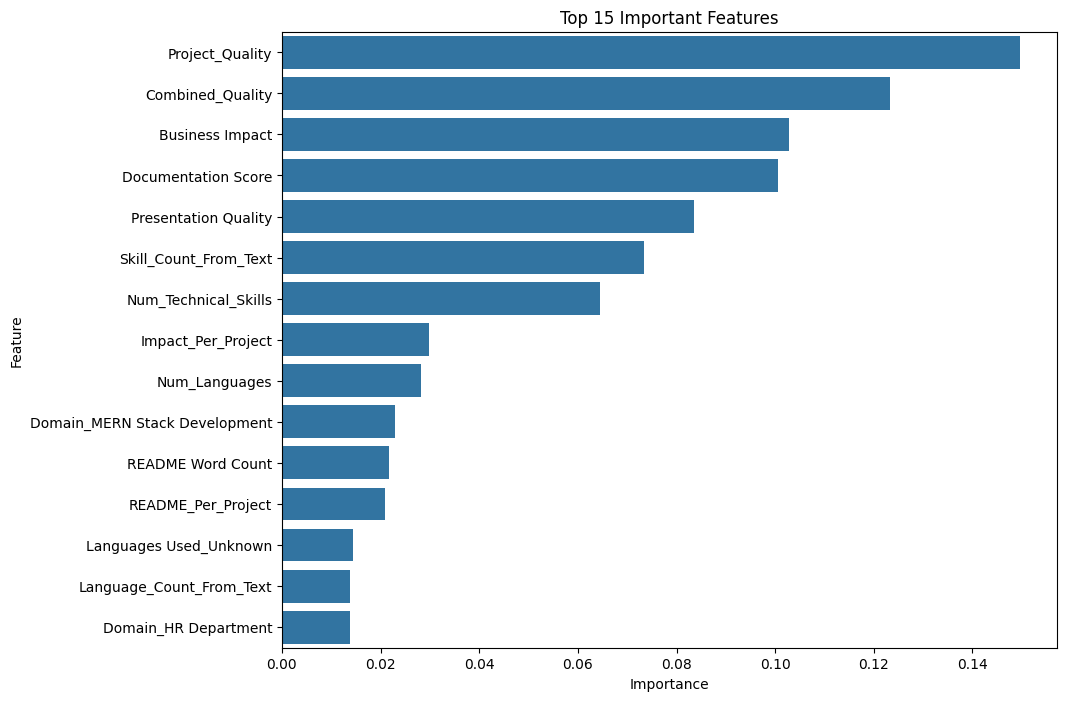

In [18]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title('Top 15 Important Features')

plt.show()

# 19. GENERATE READINESS SCORE (0-100)

In [19]:
# Predict class probabilities

probabilities = best_model.predict_proba(X_test)

readiness_scores = []

for prob in probabilities:

    # Weighted scoring system

    score = (
        prob[0] * 30 +
        prob[1] * 70 +
        prob[2] * 100
    )

    readiness_scores.append(round(score, 2))

# ------------------------------------------------------------
# Create prediction dataframe
# ------------------------------------------------------------

prediction_df = X_test.copy()

prediction_df['Predicted_Class'] = best_model.predict(X_test)

prediction_df['Readiness_Score'] = readiness_scores

# ------------------------------------------------------------
# Convert numeric labels into categories
# ------------------------------------------------------------

label_mapping = {
    0: 'Needs Improvement',
    1: 'Almost Ready',
    2: 'Job Ready'
}

prediction_df['Predicted_Category'] = prediction_df[
    'Predicted_Class'
].map(label_mapping)

# ------------------------------------------------------------
# Display sample predictions
# ------------------------------------------------------------

print("\n====================================================")
print("READINESS SCORE OUTPUT")
print("====================================================")

print(
    prediction_df[[
        'Readiness_Score',
        'Predicted_Category'
    ]].head(10)
)


READINESS SCORE OUTPUT
     Readiness_Score Predicted_Category
282            88.63          Job Ready
405            50.65  Needs Improvement
301            30.17  Needs Improvement
283            30.02  Needs Improvement
256            54.01       Almost Ready
360            34.42  Needs Improvement
202            30.05  Needs Improvement
101            96.68          Job Ready
149            98.59          Job Ready
438            49.37  Needs Improvement


# 20. SAVE BEST MODEL

In [20]:

joblib.dump(
    best_model,
    'best_intern_readiness_model.pkl'
)

print("\n====================================================")
print("MODEL SAVED SUCCESSFULLY")
print("====================================================")


MODEL SAVED SUCCESSFULLY
